In [1]:
import os
import glob

import numpy as np
import xarray as xr

import csv
import pop_tools
import gsw

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cmocean.cm as cmo
import cartopy
import matplotlib.ticker as ticker
from matplotlib import animation, gridspec
from matplotlib.gridspec import GridSpec

ccrs = cartopy.crs
cfeature = cartopy.feature

In [2]:
grid_name = 'POP_gx1v7'
region_defs = {
    'SubpolarAtlantic':[
        {'match': {'REGION_MASK': [6]}, 'bounds': {'TLAT': [10.0, 80.0], 'TLONG': [260.0, 360.0]}}   
    ],
    'NordicSea': [
        {'match': {'REGION_MASK': [9]}, 'bounds': {'TLAT': [10.0, 70.0], 'TLONG': [260.0, 360.0]}}
    ],
    'LabradorSea': [
        {'match': {'REGION_MASK': [8]}}]}
contour_mask = pop_tools.region_mask_3d(grid_name, region_defs=region_defs, mask_name='North Atlantic')
contour_mask = contour_mask.sum('region')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
# AMS widths in inches
one_col = 3.167  # 19 picas
two_col = 6.5    # 39 picas

# Set defaults
plt.rcParams.update({
    'figure.figsize': (two_col, two_col * 0.8),
    'font.size': 11,
    'axes.titlesize': 11,   # match global font size for titles
    'savefig.dpi': 300,
})

# Plot schemativ in density with fields

In [4]:
# --- Data Loading 
# Case 1: Increase
ds_temp_above = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_TEMP_3.0_40_20.nc').roll(nlon=+100)
ds_salt_above = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_SALT_3.0_40_20.nc').roll(nlon=+100)
ds_hmxl_above = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Above_combined_HMXL_3.0_40_20.nc').roll(nlon=+100)

# Case 2: Pre-85 Decrease (aa)
ds_temp_aa = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_TEMP_2.0_40_20_aa_hist.nc').roll(nlon=+100)
ds_salt_aa = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_SALT_2.0_40_20_aa_hist.nc').roll(nlon=+100)
ds_hmxl_aa = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_HMXL_2.0_40_20_aa_hist.nc').roll(nlon=+100)

# Case 3: Post-85 Decrease (ghg)
ds_temp_ghg = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_TEMP_3.0_40_20.nc').roll(nlon=+100)
ds_salt_ghg = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_SALT_3.0_40_20.nc').roll(nlon=+100)
ds_hmxl_ghg = xr.open_dataset('/Data/skd/scratch/innag3580/comp/composites/Below_combined_HMXL_3.0_40_20.nc').roll(nlon=+100)

In [5]:
def clean_latlon(ds, replacement_value=0):
    """Replace NaN, inf, or masked values in TLAT/TLONG with replacement_value."""
    for coord in ['TLAT', 'TLONG']:
        ds[coord] = xr.where(
            np.logical_or(
                np.isnan(ds[coord]),
                np.isinf(ds[coord]) | np.ma.getmask(ds[coord])
            ),
            replacement_value,
            ds[coord]
        )
    return ds

def calculate_weighted_sigma2_anomaly_map(ds_temp, ds_salt, years_slice):
    
    # 1. Calculate Potential Density (sigma2)
    CT = gsw.conversions.CT_from_pt(ds_salt['SALT'], ds_temp['TEMP'])
    sigma2 = gsw.density.sigma2(ds_salt['SALT'], CT)
    
    # 2. Select 0-500m layer and merge for weighting
    slice_upper_500 = slice(5e2, 5.5e3)
    ds_dens = ds_temp.sel(z_t=slice_upper_500).copy()
    ds_dens['DENS2'] = sigma2.sel(z_t=slice_upper_500)
    
    # 3. Calculate Volume Weights (dz * TAREA)
    weights = (ds_dens.dz * ds_dens.TAREA).fillna(0)
    
    # 4. Calculate Anomaly and Depth-Weighting
    baseline_upper = ds_dens.DENS2.isel(time=slice(0, 40)).mean('time')
    sigma2_anom = ds_dens.DENS2 - baseline_upper
    
    # Apply volume weighting and calculate depth mean ('z_t')
    sigma2_anom_weighted_depth_mean = sigma2_anom.weighted(weights).mean(dim='z_t')
    
    # 5. Calculate the final time mean
    final_map = sigma2_anom_weighted_depth_mean.isel(time=slice(*years_slice)).mean('time')

    return final_map.rename('DENS2_ANOM')

def process_hmxl(ds_hmxl, years_slice):
    
    # Calculate anomaly (subtract baseline mean of first 40 steps)
    ds_hmxl_anom = ds_hmxl - ds_hmxl.isel(time=slice(0, 40)).mean('time')
    
    # Calculate time mean and apply contour_mask (assuming it's defined globally)
    final_map = ds_hmxl_anom.isel(time=slice(*years_slice)).mean('time').where(contour_mask==1, drop=True)
    
    return final_map

In [6]:
years_ranges = [(25, 35), (35, 45), (45, 55)]

In [7]:
# --- Processing density anomalies---
# Case 1 (Increase)
ds_0_0 = calculate_weighted_sigma2_anomaly_map(ds_temp_above, ds_salt_above, years_ranges[0])
ds_0_1 = calculate_weighted_sigma2_anomaly_map(ds_temp_above, ds_salt_above, years_ranges[1])
ds_0_2 = calculate_weighted_sigma2_anomaly_map(ds_temp_above, ds_salt_above, years_ranges[2])

# Case 2 (aa)
ds_1_0 = calculate_weighted_sigma2_anomaly_map(ds_temp_aa, ds_salt_aa, years_ranges[0])
ds_1_1 = calculate_weighted_sigma2_anomaly_map(ds_temp_aa, ds_salt_aa, years_ranges[1])
ds_1_2 = calculate_weighted_sigma2_anomaly_map(ds_temp_aa, ds_salt_aa, years_ranges[2])

# Case 3 (ghg)
ds_2_0 = calculate_weighted_sigma2_anomaly_map(ds_temp_ghg, ds_salt_ghg, years_ranges[0])
ds_2_1 = calculate_weighted_sigma2_anomaly_map(ds_temp_ghg, ds_salt_ghg, years_ranges[1])
ds_2_2 = calculate_weighted_sigma2_anomaly_map(ds_temp_ghg, ds_salt_ghg, years_ranges[2])

In [8]:
#--- Process HMXL Anomalies (Rolling is needed here for consistency with your previous script) ---
ds_hmxl_0_0 = process_hmxl(ds_hmxl_above, years_ranges[0])
ds_hmxl_0_1 = process_hmxl(ds_hmxl_above, years_ranges[1])
ds_hmxl_0_2 = process_hmxl(ds_hmxl_above, years_ranges[2])

In [9]:
ds_hmxl_1_0 = process_hmxl(ds_hmxl_aa, years_ranges[0])
ds_hmxl_1_1 = process_hmxl(ds_hmxl_aa, years_ranges[1])
ds_hmxl_1_2 = process_hmxl(ds_hmxl_aa, years_ranges[2])

In [10]:
ds_hmxl_2_0 = process_hmxl(ds_hmxl_ghg, years_ranges[0])
ds_hmxl_2_1 = process_hmxl(ds_hmxl_ghg, years_ranges[1])
ds_hmxl_2_2 = process_hmxl(ds_hmxl_ghg, years_ranges[2])

In [11]:
# --- Final List Preparation ---
ds_maps = [ds_0_0, ds_0_1, ds_0_2,
           ds_1_0, ds_1_1, ds_1_2,
           ds_2_0, ds_2_1, ds_2_2]

ds_hmxl = [ds_hmxl_0_0, ds_hmxl_0_1, ds_hmxl_0_2,
           ds_hmxl_1_0, ds_hmxl_1_1, ds_hmxl_1_2,
           ds_hmxl_2_0, ds_hmxl_2_1, ds_hmxl_2_2]

In [12]:
# --- Apply clean_latlon to all final map products ---

# Apply cleaning to the 9 Density Anomaly maps (ds_maps)
ds_maps_cleaned = [clean_latlon(ds) for ds in ds_maps]

# Apply cleaning to the 9 HMXL Contour maps (ds_hmxl)
ds_hmxl_cleaned = [clean_latlon(ds) for ds in ds_hmxl]

In [13]:
# --- Shared Variables (Ensuring they are defined for the plotting script) ---
hmxl_levels = [-20000, -15000, -10000, -5000, 0, 5000, 10000, 15000, 20000]
#vmins = [-0.25] * 9 
vmins = [-0.2] * 9 
cmaps = [cmo.curl_r] * 9
vname = ['DENS2_ANOM'] * 9

row_names = ['Increase', 'Pre-85\nDecrease', 'Post-85\nDecrease']
column_names = ['Pre-Shift (25-35 years)', 'Shift (35-45 years)', 'Post-Shift (45-55 years)']

# Define the coast feature once
nature_coast = cartopy.feature.NaturalEarthFeature('physical', 'land', '50m',
                                 linewidth=0.3, edgecolor='black', facecolor='whitesmoke')

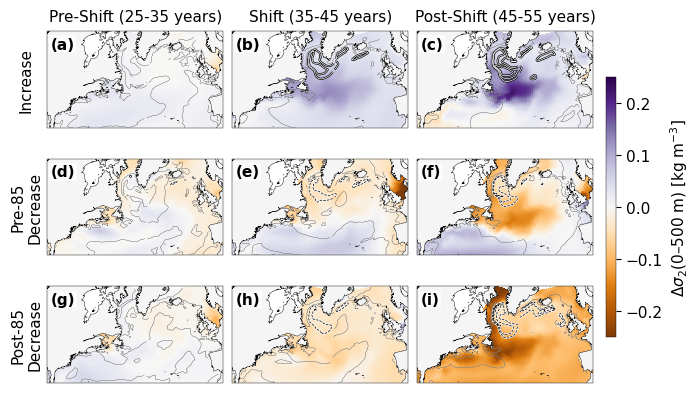

In [32]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cartopy.crs as ccrs
import numpy as np

# --- 1. Figure Setup ---
fig, axs = plt.subplots(3, 3, subplot_kw={'projection': ccrs.Orthographic(central_latitude=35, central_longitude=-35)})
pc = None 

# --- 2. Column Titles ---
for col, col_name in enumerate(column_names): 
    axs[0, col].set_title(col_name, pad=7)

# --- 3. Plotting Loop ---
for i, (ax, dsi, vname_i, cont) in enumerate(zip(axs.flat, ds_maps, vname, ds_hmxl)):
    vmin, vmax = -0.25, 0.25
    #vmin, vmax = -0.3, 0.3
    
    # Background map
    pc = ax.pcolormesh(dsi['TLONG'], dsi['TLAT'], dsi, transform=ccrs.PlateCarree(), 
                       cmap=plt.cm.PuOr, vmin=vmin, vmax=vmax)
    
    # --- MLD Contour Logic ---
    # 1. Zero Contour: Thin Solid Black with very thin white envelope
    # White base (Envelope)
    ax.contour(cont['TLONG'], cont['TLAT'], cont['HMXL'], levels=[0], 
               colors='white', linewidths=0.3, linestyles='solid', 
               transform=ccrs.PlateCarree(), zorder=5)
    # Black top (Core)
    ax.contour(cont['TLONG'], cont['TLAT'], cont['HMXL'], levels=[0], 
               colors='black', linewidths=0.2, linestyles='solid', 
               transform=ccrs.PlateCarree(), zorder=6)
    
    # 2. Positive and Negative Contours
    for level in hmxl_levels:
        if level == 0:
            continue
            
        if level < 0:
            # Negative: Black dashed line with white envelope
            # White base (Envelope)
            ax.contour(cont['TLONG'], cont['TLAT'], cont['HMXL'], levels=[level], 
                       colors='white', linewidths=1.3, linestyles='solid', 
                       transform=ccrs.PlateCarree(), zorder=4)
            # Black top (Dashed Core)
            ax.contour(cont['TLONG'], cont['TLAT'], cont['HMXL'], levels=[level], 
                       colors='black', linewidths=0.5, linestyles='dashed', 
                       transform=ccrs.PlateCarree(), zorder=5)
        else:
            # Positive: White line with black envelope
            # Black base (Envelope)
            ax.contour(cont['TLONG'], cont['TLAT'], cont['HMXL'], levels=[level], 
                       colors='black', linewidths=1.5, linestyles='solid', 
                       transform=ccrs.PlateCarree(), zorder=4)
            # White top (Solid Core)
            ax.contour(cont['TLONG'], cont['TLAT'], cont['HMXL'], levels=[level], 
                       colors='white', linewidths=0.5, linestyles='solid', 
                       transform=ccrs.PlateCarree(), zorder=5)
    
    # Map Aesthetics
    ax.set_extent([-90, -5, 35, 65], crs=ccrs.PlateCarree())
    ax.add_feature(nature_coast)
    
    for spine in ax.spines.values(): 
        spine.set_linewidth(0.3)
    
    # Labels (a, b, c...)
    label_text = f"({chr(97 + i)})"
    ax.text(0.02, 0.94, label_text, transform=ax.transAxes, fontweight='bold',
            verticalalignment='top',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1),
            zorder=15)
            
    # Row Labels
    if i % 3 == 0: 
        ax.text(-0.12, 0.5, row_names[i//3], transform=ax.transAxes, 
                va='center', ha='center', rotation=90)

# --- 4. Final Adjustments ---
# Increased negative hspace to -0.25 for tighter row stacking
# Adjusted top/bottom to prevent clipping
plt.subplots_adjust(hspace=-0.4, wspace=0.05, top=0.95, bottom=0.05, left=0.08, right=0.92)

# Specific Colorbar placement
cbar_ax = fig.add_axes([0.94, 0.25, 0.015, 0.5])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='vertical')

# Copernicus Standard Units
cbar.set_label(r'$\Delta \sigma_2$(0–500 m) [kg m$^{-3}$]')
cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.set_ticks_position('right')
cbar.locator = ticker.MaxNLocator(nbins=5) 
cbar.update_ticks()

for spine in cbar.ax.spines.values(): 
    spine.set_linewidth(0.3)

plt.savefig('Figure_Schematic.png', bbox_inches='tight', transparent=False, dpi=300)